<a href="https://www.kaggle.com/code/abidinawres/age-gender-detection-deepl-tuned-on-children?scriptVersionId=268472058" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [ ]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import tensorflow as tf

from src.config import gender_mapping, CROP_DIR
from src.data.dataset_utkface import load_full_dataset
from src.training.train_base import train
from src.training.fine_tune_children import fine_tune_children
from src.inference.predict import (
    load_final_model,
    predict_single_image,
    predict_child_tta,
)

2025-10-16 12:50:30.027082: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760619030.281039      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760619030.343682      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
warnings.filterwarnings('ignore')

In [ ]:
gpus = tf.config.experimental.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)


In [ ]:
Data = load_full_dataset()
print("Data shape:", Data.shape)
Data.head()

['26_0_2_20170104023102422.jpg.chip.jpg',
 '22_1_1_20170112233644761.jpg.chip.jpg',
 '21_1_3_20170105003215901.jpg.chip.jpg',
 '28_0_0_20170117180555824.jpg.chip.jpg',
 '17_1_4_20170103222931966.jpg.chip.jpg']

The labels of each face image is embedded in the file name, formated like **[age]_[gender]_[race]_[date&time].jpg**
[age] is an integer from 0 to 116, indicating the age
[gender] is either 0 (male) or 1 (female)

In [ ]:
print(Data[["age", "gender"]].describe())

100%|██████████| 23708/23708 [00:00<00:00, 562775.88it/s]


In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(Data["age"], kde=True, bins=40)
plt.title("Distribution des âges dans UTKFace")
plt.xlabel("Âge")
plt.ylabel("Nombre d'images")
plt.show()

[45, 29, 61, 45, 26]

In [ ]:
from sklearn.model_selection import train_test_split

Data_train, Data_test = train_test_split(
    Data, test_size=0.30, random_state=42
)

print(f"Total images: {len(Data)}")
print(f"Training Images (70%): {len(Data_train)}")
print(f"Testing Images (30%): {len(Data_test)}")

[0, 0, 0, 0, 0]

In [ ]:
base_model, base_history, base_eval = train()
print("\nBase model evaluation on test set:")
print(base_eval)

['/kaggle/input/utkface-new/UTKFace/45_0_0_20170117141859353.jpg.chip.jpg',
 '/kaggle/input/utkface-new/UTKFace/29_0_0_20170117130607527.jpg.chip.jpg',
 '/kaggle/input/utkface-new/UTKFace/61_0_1_20170117194549667.jpg.chip.jpg',
 '/kaggle/input/utkface-new/UTKFace/45_0_3_20170119202044372.jpg.chip.jpg',
 '/kaggle/input/utkface-new/UTKFace/26_0_3_20170104214448709.jpg.chip.jpg']

In [ ]:
hist_df = pd.DataFrame(base_history.history)
epochs_ran = hist_df.shape[0]
hist_df.head()


total images:  {23708} 
total age labels:  {23708} 
total gender labels:  {23708}


In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.plot(hist_df["loss"], label="Train Loss")
plt.plot(hist_df["val_loss"], label="Val Loss")
plt.title("Base Model - Total Loss")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(hist_df["age_output_mae"], label="Train Age MAE")
plt.plot(hist_df["val_age_output_mae"], label="Val Age MAE")
plt.title("Base Model - Age Prediction (MAE)")
plt.xlabel("Epoch")
plt.ylabel("Mean Absolute Error (years)")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(hist_df["gender_output_accuracy"], label="Train Gender Acc")
plt.plot(hist_df["val_gender_output_accuracy"], label="Val Gender Acc")
plt.title("Base Model - Gender Prediction (Accuracy)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


,image_path,age,gender
0,/kaggle/input/utkface-new/UTKFace/45_0_0_20170...,45,0
1,/kaggle/input/utkface-new/UTKFace/29_0_0_20170...,29,0
2,/kaggle/input/utkface-new/UTKFace/61_0_1_20170...,61,0
3,/kaggle/input/utkface-new/UTKFace/45_0_3_20170...,45,0
4,/kaggle/input/utkface-new/UTKFace/26_0_3_20170...,26,0


In [ ]:
tuned_model, hist_child, hist_mixed, eval_children = fine_tune_children()
print("\nFine-tuned model evaluation on children validation set:")
print(eval_children)

total images:  {23708}
Training Images (70%): 16595
Testing Images (30%): 7113


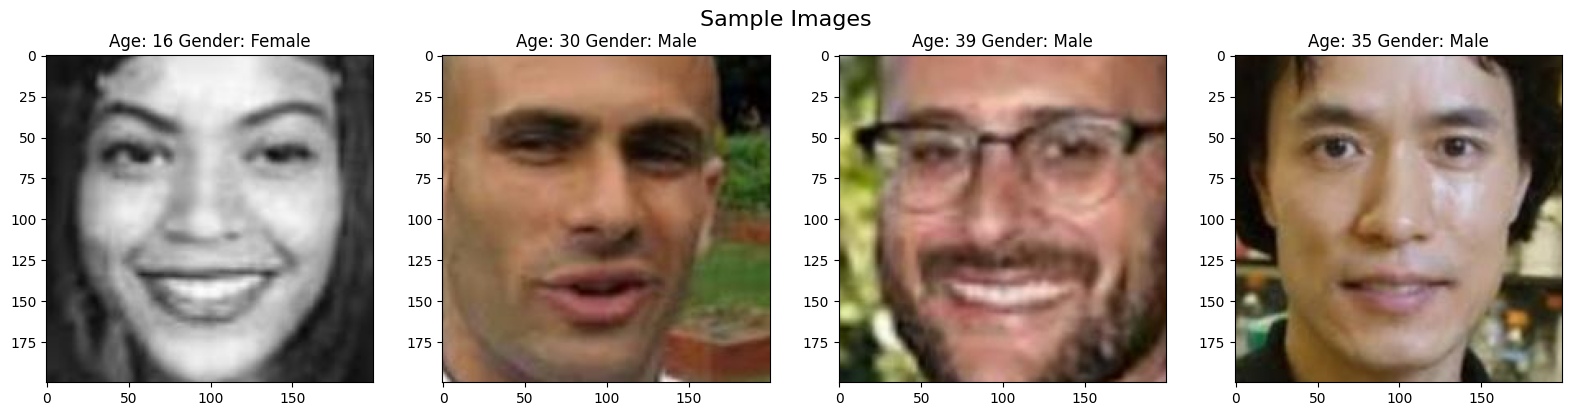

In [ ]:
hist_child_df = pd.DataFrame(hist_child.history)
hist_child_df.head()

plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.plot(hist_child_df["loss"], label="Train Loss")
plt.plot(hist_child_df["val_loss"], label="Val Loss")
plt.title("Fine-tuning Stage 1 (Children) - Total Loss")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(hist_child_df["age_output_mae"], label="Train Age MAE")
plt.plot(hist_child_df["val_age_output_mae"], label="Val Age MAE")
plt.title("Fine-tuning Stage 1 - Age MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE (years)")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(hist_child_df["gender_output_accuracy"], label="Train Gender Acc")
plt.plot(hist_child_df["val_gender_output_accuracy"], label="Val Gender Acc")
plt.title("Fine-tuning Stage 1 - Gender Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


<Axes: xlabel='age', ylabel='Density'>

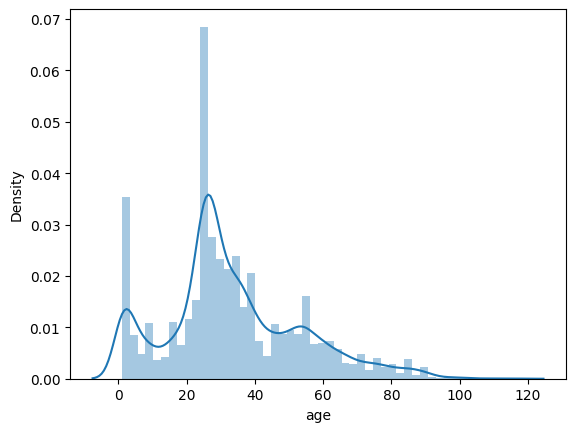

In [ ]:
hist_mixed_df = pd.DataFrame(hist_mixed.history)
hist_mixed_df.head()

plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.plot(hist_mixed_df["loss"], label="Train Loss")
plt.plot(hist_mixed_df["val_loss"], label="Val Loss")
plt.title("Fine-tuning Stage 2 (Mixed) - Total Loss")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(hist_mixed_df["age_output_mae"], label="Train Age MAE")
plt.plot(hist_mixed_df["val_age_output_mae"], label="Val Age MAE")
plt.title("Fine-tuning Stage 2 - Age MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE (years)")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(hist_mixed_df["gender_output_accuracy"], label="Train Gender Acc")
plt.plot(hist_mixed_df["val_gender_output_accuracy"], label="Val Gender Acc")
plt.title("Fine-tuning Stage 2 - Gender Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

roughly a normal distribution with slight skewness on the right, median appears to be at 27 or 28.

In [ ]:
final_model = load_final_model()

In [ ]:
TEST_IMAGE_FILE = os.path.join(
    CROP_DIR,
    "10_0_0_20170110224238891.jpg.chip.jpg"
)

if not os.path.exists(TEST_IMAGE_FILE):
    print(f"Error: Test image not found at {TEST_IMAGE_FILE}")
    print("Please ensure the crop_part1 dataset is available.")
else:
    results = predict_single_image(TEST_IMAGE_FILE, final_model)
    print("Prediction on single test image:")
    print(results)

    original_img = Image.open(TEST_IMAGE_FILE)

    plt.figure(figsize=(6, 6))
    plt.imshow(original_img, cmap="gray")
    pred_text = (
        f"Age: {results['age']} yrs\n"
        f"Gender: {results['gender']} ({results['gender_probability']:.2f})"
    )
    plt.title(pred_text, fontsize=14, fontweight="bold")
    plt.axis("off")
    plt.show()


In [ ]:
age_groups = {
    "Children (Age 0-12)": (0, 12, 3),
    "Teens (Age 13-17)": (13, 17, 3),
    "Young Adults (Age 18-21)": (18, 21, 3),
    "Adults (Age 22+)": (22, 116, 3),
}

final_test_paths = []
final_test_info = []

for group_name, (min_age, max_age, num_samples) in age_groups.items():
    group_data = Data[(Data["age"] >= min_age) & (Data["age"] <= max_age)]

    if len(group_data) < num_samples:
        print(f"Warning: Only {len(group_data)} images available for {group_name}. Sampling all.")
        sampled_data = group_data
    else:
        sampled_data = group_data.sample(n=num_samples, random_state=42)

    for _, row in sampled_data.iterrows():
        final_test_paths.append(row["image_path"])
        final_test_info.append(
            {
                "path": row["image_path"],
                "true_age": row["age"],
                "true_gender": gender_mapping[row["gender"]],
                "group": group_name,
            }
        )

print(f"Collected {len(final_test_paths)} images for final testing.")


In [ ]:
N_SAMPLES = len(final_test_paths)
N_COLS = 3
N_ROWS = int(np.ceil(N_SAMPLES / N_COLS))

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(5 * N_COLS, 6 * N_ROWS))
axes = axes.flatten()

for i, info in enumerate(final_test_info):
    results = predict_single_image(info["path"], final_model)

    original_img = Image.open(info["path"])

    gender_correct = results["gender"] == info["true_gender"]
    age_diff = abs(results["age"] - info["true_age"])

    gender_status = "CORRECT" if gender_correct else "WRONG"
    age_status = f"Diff: {age_diff} yrs"

    ax = axes[i]
    ax.imshow(original_img)

    title_text = (
        f"Group: {info['group']}\n"
        f"True: Age {info['true_age']}, Gender {info['true_gender']}\n"
        f"Pred: Age {results['age']} ({age_status})\n"
        f"Pred: Gender {results['gender']} ({results['gender_probability']:.2f}) - {gender_status}"
    )

    ax.set_title(title_text, fontsize=9, fontweight="bold")
    ax.axis("off")


In [ ]:
for j in range(len(final_test_paths), N_ROWS * N_COLS):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()